In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# place raw data here

A_normal = np.array([
    1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
    1, 0, 2, 0, 0, 1, 0, 1, 0, 0, 0, 1, 2, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
    6, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 6, 1,
    0, 2, 0, 0, 2, 6, 1, 1, 1, 0, 4, 0, 1, 1, 1, 2, 0, 0, 2, 1, 0, 1, 0, 2,
    0, 1, 0, 0, 1, 3, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0
])
P_normal = np.array([
    1, 1, 1, 1, 2, 0, 0, 0, 1, 0, 0,
    1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 4,
    0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 2, 1, 0, 1,
    0, 0, 0, 5, 1, 0, 0, 0, 3, 0, 1, 1, 1, 2, 0, 0, 1, 1, 2, 0, 0, 2, 0, 0, 1,
    1, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
])

A_aml = np.array([
    0, 2, 2, 6, 18, 12, 20, 32, 3, 8, 3, 23, 8, 4, 8, 7, 15, 16, 0, 16, 8,
    6, 2, 0, 9,
    0, 10, 2, 16, 19, 24, 21, 5, 1, 0, 41, 13, 11, 0, 5, 5,
    11, 14, 15, 13, 23, 1, 14, 2, 1, 9, 10, 37, 7, 0, 23, 9, 2, 6, 26, 1, 8,
    6, 1, 8, 25, 23, 15, 22, 12, 2, 12, 7, 18, 11, 2, 12, 2, 20, 14, 1, 13, 4, 39, 1, 14, 0
])
P_aml = np.array([
    0, 9, 3, 4, 17, 10, 21, 24, 3, 8, 10, 20, 8, 3, 9, 6, 19, 12, 9, 11, 8,
    7, 1, 1, 9,
    3, 11, 2, 15, 19, 22, 22, 5, 0, 1, 37, 14, 10, 0, 5, 5,
    13, 14, 15, 11, 21, 1, 17, 1, 2, 8, 10, 34, 10, 0, 23, 8, 9, 13, 22, 11, 15, 12, 9, 7,
    24, 18, 13, 19, 10, 2, 8, 9, 27, 11, 1, 12, 2, 20, 16, 12, 17, 6, 36, 0, 12, 4
])

if len(A_normal) != len(P_normal):
    raise ValueError("A_normal and P_normal must have the same length.")

if len(A_aml) != len(P_aml):
    raise ValueError("A_aml and P_aml must have the same length.")

print(len(A_normal), len(P_normal), len(A_aml), len(P_aml))

99 99 87 87


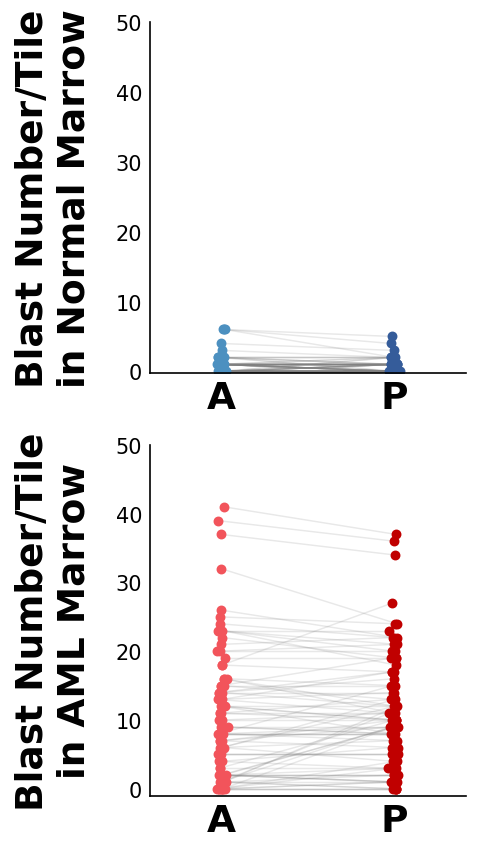

In [8]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(3.4, 5.8),
    dpi=150,
    sharex=True
)

rng = np.random.default_rng(42)
xA, xP = 1, 2.2

# top = Normal (blue), bottom = AML (red)
panel_data = [
    (axes[0], A_normal, P_normal, 'Blast Number/Tile\nin Normal Marrow', '#4C90C0', '#355C9A'),
    (axes[1], A_aml,    P_aml,    'Blast Number/Tile\nin AML Marrow',    '#F2545B', '#C00000')
]

for ax, A_counts, P_counts, ylabel, color_A, color_P in panel_data:
    jA = rng.normal(0, 0.015, len(A_counts))
    jP = rng.normal(0, 0.015, len(P_counts))

    # paired lines
    for a, p, ja, jp in zip(A_counts, P_counts, jA, jP):
        ax.plot(
            [xA + ja, xP + jp],
            [a, p],
            color='gray',
            alpha=0.18,
            linewidth=0.7,
            zorder=1
        )

    # points
    ax.scatter(
        np.full(len(A_counts), xA) + jA,
        A_counts,
        s=14,
        color=color_A,
        zorder=2
    )
    ax.scatter(
        np.full(len(P_counts), xP) + jP,
        P_counts,
        s=14,
        color=color_P,
        zorder=2
    )

    ax.set_xlim(0.5, 2.7)
    ax.set_ylabel(ylabel, fontsize=18, fontweight='bold', rotation=90)
    ax.tick_params(axis='y', labelsize=10, length=0)
    ax.tick_params(axis='x', length=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

for ax in axes:
    ax.set_xticks([xA, xP])
    ax.set_xticklabels(['A', 'P'], fontsize=18, fontweight='bold')
    ax.tick_params(axis='x', labelbottom=True)

axes[0].set_ylim(-0.2, 50)
axes[1].set_ylim(-1, 50)

axes[0].yaxis.set_label_coords(-0.18, 0.5)
axes[1].yaxis.set_label_coords(-0.18, 0.5)

plt.tight_layout(h_pad=1.0)
plt.show()